In [2]:
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np
import cv2 as cv

c:\Users\Diogo\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\Diogo\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\Diogo\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framewo

In [3]:
# Step 1: Load MNIST data
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.mnist.load_data()

# Preprocess the images: Normalize and flatten them
train_images = train_images.reshape((train_images.shape[0], 28, 28, 1)).astype('float32') / 255.0
test_images = test_images.reshape((test_images.shape[0], 28, 28, 1)).astype('float32') / 255.0

In [ ]:
# Step 2: Build a simple DNN model
model = models.Sequential()
model.add(layers.Flatten(input_shape=(28, 28, 1)))  # Flatten the 28x28 image to a vector
model.add(layers.Dense(128, activation='relu'))  # Dense layer with 128 neurons
model.add(layers.Dense(10, activation='softmax'))  # Output layer with 10 classes (digits 0-9)

# Step 3: Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Step 4: Train the model
model.fit(train_images, train_labels, epochs=1, batch_size=64, validation_data=(test_images, test_labels))

# Step 5: Save the trained model
save_path = "mnist_model.keras"
model.save(save_path)
print("Model saved to " + save_path) 

c:\Users\Diogo\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8537 - loss: 0.5163 - val_accuracy: 0.9494 - val_loss: 0.1726
Model saved to mnist_model.keras


In [ ]:
pre_model = tf.keras.models.load_model("mnist_model.h5")
pre_model.export("saved_model")

INFO:tensorflow:Assets written to: saved_model\assets


INFO:tensorflow:Assets written to: saved_model\assets


Saved artifact at 'saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 28, 28, 1), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  2109672445456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2109672442576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2109672445648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2109672442384: TensorSpec(shape=(), dtype=tf.resource, name=None)


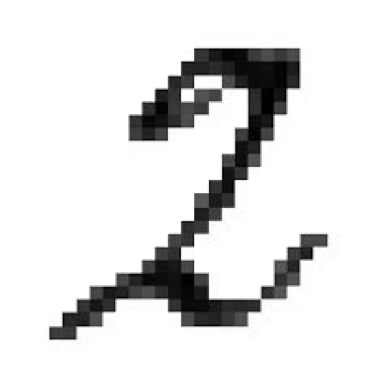

In [15]:
image = cv.imread("Aula_10_files/Aula_10_images_files/2.jpg", cv.IMREAD_GRAYSCALE)

plt.imshow(image, cmap="gray")
plt.axis('off')
plt.show()

In [ ]:
image = cv.dnn.blobFromImage(image, 1.0, (28, 28), [104, 117, 123], swapRB=False, crop=False)

In [17]:
display(image.shape)

(1, 1, 28, 28)

In [ ]:
# Step 6: Load the model in OpenCV
# Convert the TensorFlow model to OpenCV format (using DNN module in OpenCV)
# OpenCV DNN module uses models saved in the "TensorFlow SavedModel" or "TF Lite" formats

# First, we need to convert the model to a format that OpenCV can read:
# Use TensorFlow's SavedModel format

#model.save(".TP10\\mnist_saved_model")

# Step 7: Load the model in OpenCV
# OpenCV DNN module can load models in the TensorFlow SavedModel format
net = cv.dnn.readNetFromTensorflow("saved_model/fingerprint.pb")

# Step 8: Test the model with OpenCV
# Prepare an image for testing (let's take the first image from the test set)
image = cv.imread("Aula_10_files/Aula_10_images_files/2.jpg", cv.IMREAD_GRAYSCALE)

# Convert the image to a format suitable for OpenCV's DNN module (HWC, float32)
blob = cv.dnn.blobFromImage(image, 1.0, (28, 28), [104, 117, 123], swapRB=False, crop=False)

# Perform forward pass with OpenCV's DNN
net.setInput(blob)
output = net.forward()

# Print the output (probabilities for each digit 0-9)
print("Output from OpenCV DNN forward pass: ", output)

# Get the predicted digit
predicted_digit = np.argmax(output)
print(f"Predicted digit: {predicted_digit}")

error: OpenCV(4.12.0) D:\a\opencv-python\opencv-python\opencv\modules\dnn\src\net.cpp:80: error: (-215:Assertion failed) !empty() in function 'cv::dnn::dnn4_v20250619::Net::forward'
